Hybrid Quantum GAN where both Generator and Discriminator have VQC embedded within classical NN training on the MNIST dataset. I started with 4 qubits, then implemented 8 qubit and tunned the hyperparameters. 


4 qubits

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import pennylane as qml
from pennylane.qnn import TorchLayer
import os
import torch.nn.functional as F
from torchvision.utils import make_grid, save_image
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import matplotlib.pyplot as plt


Epoch  1 | D-loss: 0.4916 | G-loss: 0.9580
Epoch  2 | D-loss: 0.5547 | G-loss: 0.8778
Epoch  3 | D-loss: 0.5379 | G-loss: 0.9137
Epoch  4 | D-loss: 0.5117 | G-loss: 0.9683
Epoch  5 | D-loss: 0.4973 | G-loss: 1.0102
Epoch  6 | D-loss: 0.4796 | G-loss: 1.0427
Epoch  7 | D-loss: 0.4611 | G-loss: 1.0745
Epoch  8 | D-loss: 0.4450 | G-loss: 1.1092
Epoch  9 | D-loss: 0.4280 | G-loss: 1.1432
Epoch 10 | D-loss: 0.4133 | G-loss: 1.1774
Epoch 11 | D-loss: 0.3987 | G-loss: 1.2091
Epoch 12 | D-loss: 0.3856 | G-loss: 1.2415
Epoch 13 | D-loss: 0.3748 | G-loss: 1.2801
Epoch 14 | D-loss: 0.3622 | G-loss: 1.3189
Epoch 15 | D-loss: 0.3504 | G-loss: 1.3503
Epoch 16 | D-loss: 0.3393 | G-loss: 1.3856
Epoch 17 | D-loss: 0.3286 | G-loss: 1.4264
Epoch 18 | D-loss: 0.3189 | G-loss: 1.4619
Epoch 19 | D-loss: 0.3115 | G-loss: 1.4982
Epoch 20 | D-loss: 0.3023 | G-loss: 1.5322
Epoch 21 | D-loss: 0.2959 | G-loss: 1.5662
Epoch 22 | D-loss: 0.2854 | G-loss: 1.6071
Epoch 23 | D-loss: 0.2799 | G-loss: 1.6444
Epoch 24 | 

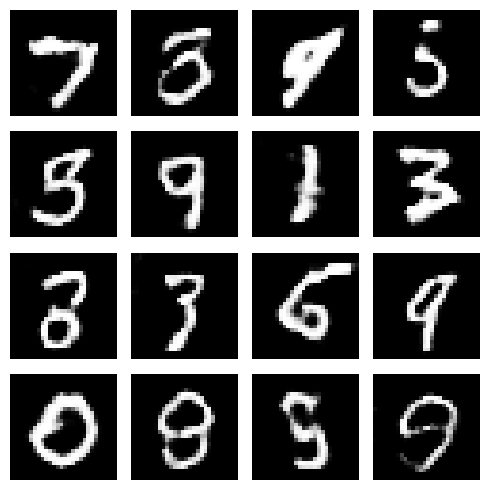

In [ ]:
batch_size = 128
latent_dim = 100
n_qubits   = 4
q_depth    = 3
lr         = 1e-4
n_epochs   = 30
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_loader = DataLoader(
    datasets.MNIST(".", train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev, interface="torch")
def qcircuit(inputs, weights):
    # angle‐encode
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]
weight_shapes = {"weights": (q_depth, n_qubits)}
quantum_layer = TorchLayer(qcircuit, weight_shapes).to(device)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.init_size = 7
        # map z → 128×7×7
        self.fc = nn.Linear(latent_dim, 128 * self.init_size**2)
        self.pre_q = nn.Linear(128, n_qubits)
        self.post_q = nn.Linear(n_qubits, 128)
        self.upsample = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),          # 14×14
            nn.Conv2d(128, 64, 3, padding=1),     
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2),          # 28×28
            nn.Conv2d(64, 1, 3, padding=1),
            nn.Tanh()                             # pixels in [–1,1]
        )

    def forward(self, z):
        batch = z.size(0)
        x = self.fc(z).view(batch, 128, self.init_size, self.init_size)

        # global‐pool → [batch,128]
        feat = x.mean(dim=[2,3])
        # prepare angles in [–π,π]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi
        q_out = quantum_layer(angles)
        # back to 128 channels
        fusion = self.post_q(q_out).view(batch, 128, 1, 1)
        x = x * (1 + fusion)
        img = self.upsample(x)
        return img


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), # 14×14
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),# 7×7
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),
            nn.Flatten(),                             # → batch×(32·7·7)
        )
        self.fc1 = nn.Linear(32*7*7, 128)
        self.pre_q = nn.Linear(128, n_qubits)
        self.post_q = nn.Linear(n_qubits, 1)

    def forward(self, img):
        batch = img.size(0)
        x = self.down(img)
        feat = torch.relu(self.fc1(x))
        angles = torch.tanh(self.pre_q(feat)) * torch.pi
        q_out = quantum_layer(angles)
        validity = torch.sigmoid(self.post_q(q_out))
        return validity


G = Generator().to(device)
D = Discriminator().to(device)
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5,0.999))
criterion = nn.BCELoss()

for epoch in range(1, n_epochs+1):
    g_loss_acc, d_loss_acc = 0., 0.
    for real, _ in train_loader:
        real = real.to(device)
        b = real.size(0)
        ones = torch.ones(b,1, device=device)
        zeros= torch.zeros(b,1, device=device)

        #Discriminator
        opt_D.zero_grad()
        d_real = D(real)
        loss_real = criterion(d_real, ones)
        z = torch.randn(b, latent_dim, device=device)
        fake = G(z).detach()
        d_fake = D(fake)
        loss_fake = criterion(d_fake, zeros)

        d_loss = (loss_real + loss_fake)/2
        d_loss.backward()
        opt_D.step()

        #generator
        opt_G.zero_grad()
        z = torch.randn(b, latent_dim, device=device)
        gen = G(z)
        g_loss = criterion(D(gen), ones)
        g_loss.backward()
        opt_G.step()

        d_loss_acc += d_loss.item()
        g_loss_acc += g_loss.item()

    print(f"Epoch {epoch:2d} | D-loss: {d_loss_acc/len(train_loader):.4f} | "
          f"G-loss: {g_loss_acc/len(train_loader):.4f}")

import matplotlib.pyplot as plt

G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = G(z).cpu().squeeze().numpy()

fig, axs = plt.subplots(4,4, figsize=(5,5))
for ax, img in zip(axs.flatten(), samples):
    ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
plt.tight_layout()
plt.show()


Classifier Epoch 1/3 – Accuracy: 0.9438
Classifier Epoch 2/3 – Accuracy: 0.9843
Classifier Epoch 3/3 – Accuracy: 0.9885
FID:                 67.90
Inception Score:     1.07 ± 0.03
Mode Collapse Rate:  0.0%
PSNR:                8.81
SSIM:                0.212


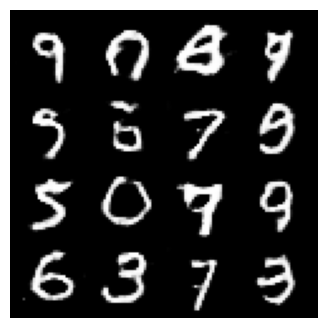

In [ ]:

cla_batch = 64
cla_transform = transforms.ToTensor()  # [0,1]
cla_train_loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=cla_transform),
    batch_size=cla_batch, shuffle=True
)

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),  # 28×28 → 28×28
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 14×14
            nn.Conv2d(32, 64, 3, 1, 1), # → 14×14
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 7×7
            nn.Flatten(),               # → 64*7*7
            nn.Linear(64*7*7, 128),
            nn.ReLU(True),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

classifier = MNISTClassifier().to(device)
opt_C = optim.Adam(classifier.parameters(), lr=1e-3)
criterion_C = nn.CrossEntropyLoss()

for epoch in range(3):
    classifier.train()
    total, correct = 0, 0
    for imgs, labels in cla_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = classifier(imgs)
        loss = criterion_C(logits, labels)
        opt_C.zero_grad(); loss.backward(); opt_C.step()

        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    acc = correct / total
    print(f"Classifier Epoch {epoch+1}/3 – Accuracy: {acc:.4f}")


def compute_fid(real_imgs: torch.Tensor, fake_imgs: torch.Tensor, device=device) -> float:
    real_uint8 = (real_imgs * 255).to(torch.uint8)
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    fid = FrechetInceptionDistance(feature=2048).to(device)
    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    return fid.compute().item()

def compute_inception_score(fake_imgs: torch.Tensor, device=device):
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    is_metric = InceptionScore(feature=2048).to(device)
    is_metric.update(fake_uint8)
    mean, std = is_metric.compute()
    return mean.item(), std.item()

def compute_mode_collapse(model, classifier, n_images=10000, device=device) -> float:
    model.eval(); classifier.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, device=device)
        fake = (model(z) + 1) / 2.0
        preds = classifier(fake).argmax(dim=1).cpu().tolist()
    seen = len(set(preds))
    return (1 - seen / 10.0) * 100 

def compute_psnr_ssim(real_images: torch.Tensor, fake_images: torch.Tensor):
    real_np = real_images.cpu().numpy()
    fake_np = fake_images.cpu().numpy()
    psnr_vals, ssim_vals = [], []
    for r, f in zip(real_np, fake_np):
        r2, f2 = r.squeeze(), f.squeeze()
        psnr_vals.append(psnr(r2, f2, data_range=1.0))
        ssim_vals.append(ssim(r2, f2, data_range=1.0))
    return sum(psnr_vals)/len(psnr_vals), sum(ssim_vals)/len(ssim_vals)


G.eval()

real_batch, _ = next(iter(train_loader))
real_small = (real_batch.to(device) + 1) / 2            # [0,1], [B,1,28,28]
real_for_fid = real_small.repeat(1,3,1,1)               # [B,3,28,28]
real_for_fid = F.interpolate(real_for_fid, size=(299,299), mode='bilinear')

with torch.no_grad():
    z = torch.randn(real_for_fid.size(0), latent_dim, device=device)
    fake_small = G(z).cpu().clamp(-1,1).add(1).div(2)   # [0,1], [B,1,28,28]
fake_for_fid = fake_small.repeat(1,3,1,1)
fake_for_fid = F.interpolate(fake_for_fid, size=(299,299), mode='bilinear')

fid_val = compute_fid(real_for_fid, fake_for_fid, device)
print(f"FID:                 {fid_val:.2f}")

is_mean, is_std = compute_inception_score(fake_for_fid, device)
print(f"Inception Score:     {is_mean:.2f} ± {is_std:.2f}")

mode_rate = compute_mode_collapse(G, classifier, device=device)
print(f"Mode Collapse Rate:  {mode_rate:.1f}%")

psnr_val, ssim_val = compute_psnr_ssim(real_small.cpu(), fake_small)
print(f"PSNR:                {psnr_val:.2f}")
print(f"SSIM:                {ssim_val:.3f}")

with torch.no_grad():
    z2 = torch.randn(16, latent_dim, device=device)
    samples = (G(z2).cpu().clamp(-1,1).add(1).div(2))   # [0,1], [16,1,28,28]
grid = make_grid(samples, nrow=4)
plt.figure(figsize=(4,4))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()


Now, we will encode 16 angle values instead of 4 to leverage more quantum circuit. We wil be using 8 qubit with Rx and Ry angle encoding. 

Epoch  1 | D-loss: 0.5544 | G-loss: 0.7009
Epoch  2 | D-loss: 0.5816 | G-loss: 0.7169
Epoch  3 | D-loss: 0.5735 | G-loss: 0.7380
Epoch  4 | D-loss: 0.5474 | G-loss: 0.7893
Epoch  5 | D-loss: 0.5259 | G-loss: 0.8356
Epoch  6 | D-loss: 0.5059 | G-loss: 0.8842
Epoch  7 | D-loss: 0.4877 | G-loss: 0.9326
Epoch  8 | D-loss: 0.4684 | G-loss: 0.9827
Epoch  9 | D-loss: 0.4521 | G-loss: 1.0313
Epoch 10 | D-loss: 0.4351 | G-loss: 1.0767
Epoch 11 | D-loss: 0.4192 | G-loss: 1.1215
Epoch 12 | D-loss: 0.4043 | G-loss: 1.1655
Epoch 13 | D-loss: 0.3888 | G-loss: 1.2035
Epoch 14 | D-loss: 0.3746 | G-loss: 1.2431
Epoch 15 | D-loss: 0.3637 | G-loss: 1.2831
Epoch 16 | D-loss: 0.3503 | G-loss: 1.3187
Epoch 17 | D-loss: 0.3398 | G-loss: 1.3617
Epoch 18 | D-loss: 0.3287 | G-loss: 1.4014
Epoch 19 | D-loss: 0.3177 | G-loss: 1.4382
Epoch 20 | D-loss: 0.3096 | G-loss: 1.4795
Epoch 21 | D-loss: 0.3000 | G-loss: 1.5170
Epoch 22 | D-loss: 0.2908 | G-loss: 1.5613
Epoch 23 | D-loss: 0.2813 | G-loss: 1.6009
Epoch 24 | 

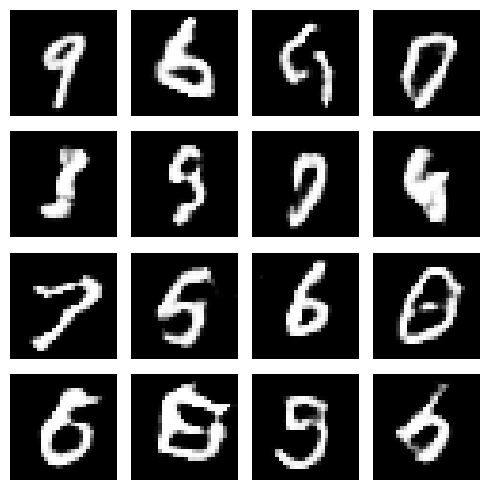

In [ ]:
batch_size = 128
latent_dim = 100
n_qubits   = 8          
q_depth    = 3
lr         = 1e-4
n_epochs   = 30
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_loader = DataLoader(
    datasets.MNIST(".", train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qcircuit(inputs, weights):
    for i in range(n_qubits):
        qml.RX(inputs[..., i],         wires=i)
        qml.RY(inputs[..., i + n_qubits], wires=i)
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]
weight_shapes = {"weights": (q_depth, n_qubits)}
quantum_layer = TorchLayer(qcircuit, weight_shapes).to(device)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.init_size = 7
        self.fc     = nn.Linear(latent_dim, 128 * self.init_size**2)
        self.pre_q  = nn.Linear(128, 2 * n_qubits)  # 16 angles
        self.post_q = nn.Linear(n_qubits, 128)
        self.upsample = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),          # → 14×14
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2),          # → 28×28
            nn.Conv2d(64, 1, 3, padding=1),
            nn.Tanh()                             # pixels in [–1,1]
        )

    def forward(self, z):
        batch = z.size(0)
        x = self.fc(z).view(batch, 128, self.init_size, self.init_size)

        feat   = x.mean(dim=[2,3])               # [batch,128]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi  # [batch,16]
        q_out  = quantum_layer(angles)           # [batch,8]
        fusion = self.post_q(q_out).view(batch, 128, 1, 1)

        img = self.upsample(x * (1 + fusion))
        return img

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), # 14×14
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),# 7×7
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),
            nn.Flatten(),                             # → [batch, 32·7·7]
        )
        self.fc1    = nn.Linear(32*7*7, 128)
        self.pre_q  = nn.Linear(128, 2 * n_qubits)  # 16 angles
        self.post_q = nn.Linear(n_qubits, 1)

    def forward(self, img):
        batch = img.size(0)
        x    = self.down(img)
        feat = torch.relu(self.fc1(x))             # [batch,128]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi  # [batch,16]
        q_out  = quantum_layer(angles)             # [batch,8]
        validity = torch.sigmoid(self.post_q(q_out))
        return validity

G = Generator().to(device)
D = Discriminator().to(device)
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5,0.999))
criterion = nn.BCELoss()

for epoch in range(1, n_epochs+1):
    g_loss_acc, d_loss_acc = 0., 0.
    for real, _ in train_loader:
        real = real.to(device)
        b    = real.size(0)
        ones = torch.ones(b,1, device=device)
        zeros= torch.zeros(b,1, device=device)

        opt_D.zero_grad()
        loss_real = criterion(D(real), ones)
        fake = G(torch.randn(b, latent_dim, device=device)).detach()
        loss_fake = criterion(D(fake), zeros)
        d_loss = 0.5 * (loss_real + loss_fake)
        d_loss.backward();  opt_D.step()

        opt_G.zero_grad()
        g_loss = criterion(D(G(torch.randn(b, latent_dim, device=device))), ones)
        g_loss.backward();  opt_G.step()
        d_loss_acc += d_loss.item()
        g_loss_acc += g_loss.item()

    print(f"Epoch {epoch:2d} | D-loss: {d_loss_acc/len(train_loader):.4f} | "
          f"G-loss: {g_loss_acc/len(train_loader):.4f}")

G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = G(z).cpu().squeeze().numpy()

fig, axs = plt.subplots(4,4, figsize=(5,5))
for ax, img in zip(axs.flatten(), samples):
    ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
plt.tight_layout()
plt.show()


Classifier Epoch 1/3 – Accuracy: 0.9466
Classifier Epoch 2/3 – Accuracy: 0.9846
Classifier Epoch 3/3 – Accuracy: 0.9889
FID:                 63.67
Inception Score:     1.05 ± 0.01
Mode Collapse Rate:  0.0%
PSNR:                8.83
SSIM:                0.218


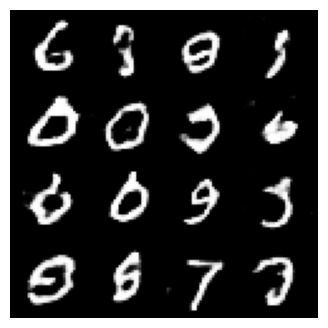

In [ ]:

cla_batch = 64
cla_transform = transforms.ToTensor()  # [0,1]
cla_train_loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=cla_transform),
    batch_size=cla_batch, shuffle=True
)

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),  # 28×28 → 28×28
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 14×14
            nn.Conv2d(32, 64, 3, 1, 1), # → 14×14
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 7×7
            nn.Flatten(),               # → 64*7*7
            nn.Linear(64*7*7, 128),
            nn.ReLU(True),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

classifier = MNISTClassifier().to(device)
opt_C = optim.Adam(classifier.parameters(), lr=1e-3)
criterion_C = nn.CrossEntropyLoss()

for epoch in range(3):
    classifier.train()
    total, correct = 0, 0
    for imgs, labels in cla_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = classifier(imgs)
        loss = criterion_C(logits, labels)
        opt_C.zero_grad(); loss.backward(); opt_C.step()

        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    acc = correct / total
    print(f"Classifier Epoch {epoch+1}/3 – Accuracy: {acc:.4f}")


def compute_fid(real_imgs: torch.Tensor, fake_imgs: torch.Tensor, device=device) -> float:
    real_uint8 = (real_imgs * 255).to(torch.uint8)
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    fid = FrechetInceptionDistance(feature=2048).to(device)
    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    return fid.compute().item()

def compute_inception_score(fake_imgs: torch.Tensor, device=device):
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    is_metric = InceptionScore(feature=2048).to(device)
    is_metric.update(fake_uint8)
    mean, std = is_metric.compute()
    return mean.item(), std.item()

def compute_mode_collapse(model, classifier, n_images=10000, device=device) -> float:
    model.eval(); classifier.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, device=device)
        fake = (model(z) + 1) / 2.0
        preds = classifier(fake).argmax(dim=1).cpu().tolist()
    seen = len(set(preds))
    return (1 - seen / 10.0) * 100 

def compute_psnr_ssim(real_images: torch.Tensor, fake_images: torch.Tensor):
    real_np = real_images.cpu().numpy()
    fake_np = fake_images.cpu().numpy()
    psnr_vals, ssim_vals = [], []
    for r, f in zip(real_np, fake_np):
        r2, f2 = r.squeeze(), f.squeeze()
        psnr_vals.append(psnr(r2, f2, data_range=1.0))
        ssim_vals.append(ssim(r2, f2, data_range=1.0))
    return sum(psnr_vals)/len(psnr_vals), sum(ssim_vals)/len(ssim_vals)


G.eval()

real_batch, _ = next(iter(train_loader))
real_small = (real_batch.to(device) + 1) / 2            # [0,1], [B,1,28,28]
real_for_fid = real_small.repeat(1,3,1,1)               # [B,3,28,28]
real_for_fid = F.interpolate(real_for_fid, size=(299,299), mode='bilinear')

with torch.no_grad():
    z = torch.randn(real_for_fid.size(0), latent_dim, device=device)
    fake_small = G(z).cpu().clamp(-1,1).add(1).div(2)   # [0,1], [B,1,28,28]
fake_for_fid = fake_small.repeat(1,3,1,1)
fake_for_fid = F.interpolate(fake_for_fid, size=(299,299), mode='bilinear')

fid_val = compute_fid(real_for_fid, fake_for_fid, device)
print(f"FID:                 {fid_val:.2f}")

is_mean, is_std = compute_inception_score(fake_for_fid, device)
print(f"Inception Score:     {is_mean:.2f} ± {is_std:.2f}")

mode_rate = compute_mode_collapse(G, classifier, device=device)
print(f"Mode Collapse Rate:  {mode_rate:.1f}%")

psnr_val, ssim_val = compute_psnr_ssim(real_small.cpu(), fake_small)
print(f"PSNR:                {psnr_val:.2f}")
print(f"SSIM:                {ssim_val:.3f}")

with torch.no_grad():
    z2 = torch.randn(16, latent_dim, device=device)
    samples = (G(z2).cpu().clamp(-1,1).add(1).div(2))   # [0,1], [16,1,28,28]
grid = make_grid(samples, nrow=4)
plt.figure(figsize=(4,4))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()


When we train for only 30 epochs, hybrid GAN shown an advantage over classical GAN. Thus, I will experiement only training for 10 epochs below. 

Epoch  1 | D-loss: 0.5788 | G-loss: 0.8259
Epoch  2 | D-loss: 0.6251 | G-loss: 0.7759
Epoch  3 | D-loss: 0.5976 | G-loss: 0.8052
Epoch  4 | D-loss: 0.5789 | G-loss: 0.8329
Epoch  5 | D-loss: 0.5632 | G-loss: 0.8578
Epoch  6 | D-loss: 0.5434 | G-loss: 0.8897
Epoch  7 | D-loss: 0.5222 | G-loss: 0.9219
Epoch  8 | D-loss: 0.5057 | G-loss: 0.9543
Epoch  9 | D-loss: 0.4879 | G-loss: 0.9845
Epoch 10 | D-loss: 0.4715 | G-loss: 1.0179


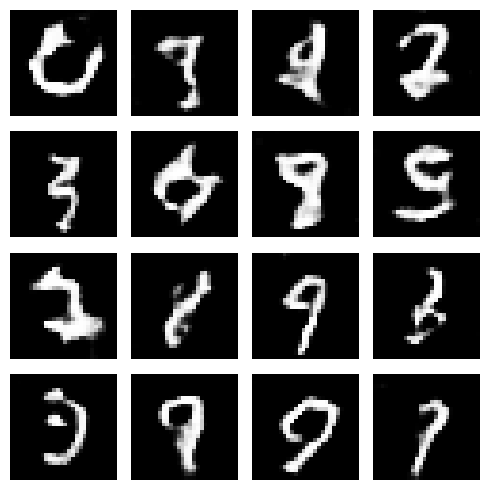

In [ ]:

batch_size = 128
latent_dim = 100
n_qubits   = 8          
q_depth    = 3
lr         = 1e-4
n_epochs   = 10
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_loader = DataLoader(
    datasets.MNIST(".", train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qcircuit(inputs, weights):
    for i in range(n_qubits):
        qml.RX(inputs[..., i],         wires=i)
        qml.RY(inputs[..., i + n_qubits], wires=i)
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]
weight_shapes = {"weights": (q_depth, n_qubits)}
quantum_layer = TorchLayer(qcircuit, weight_shapes).to(device)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.init_size = 7
        self.fc     = nn.Linear(latent_dim, 128 * self.init_size**2)
        self.pre_q  = nn.Linear(128, 2 * n_qubits)  # 16 angles
        self.post_q = nn.Linear(n_qubits, 128)
        self.upsample = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),          # → 14×14
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2),          # → 28×28
            nn.Conv2d(64, 1, 3, padding=1),
            nn.Tanh()                             # pixels in [–1,1]
        )

    def forward(self, z):
        batch = z.size(0)
        x = self.fc(z).view(batch, 128, self.init_size, self.init_size)

        feat   = x.mean(dim=[2,3])               # [batch,128]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi  # [batch,16]
        q_out  = quantum_layer(angles)           # [batch,8]
        fusion = self.post_q(q_out).view(batch, 128, 1, 1)

        img = self.upsample(x * (1 + fusion))
        return img

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.down = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), # 14×14
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),# 7×7
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),
            nn.Flatten(),                             # → [batch, 32·7·7]
        )
        self.fc1    = nn.Linear(32*7*7, 128)
        self.pre_q  = nn.Linear(128, 2 * n_qubits)  # 16 angles
        self.post_q = nn.Linear(n_qubits, 1)

    def forward(self, img):
        batch = img.size(0)
        x    = self.down(img)
        feat = torch.relu(self.fc1(x))             # [batch,128]
        angles = torch.tanh(self.pre_q(feat)) * torch.pi  # [batch,16]
        q_out  = quantum_layer(angles)             # [batch,8]
        validity = torch.sigmoid(self.post_q(q_out))
        return validity

G = Generator().to(device)
D = Discriminator().to(device)
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5,0.999))
criterion = nn.BCELoss()

for epoch in range(1, n_epochs+1):
    g_loss_acc, d_loss_acc = 0., 0.
    for real, _ in train_loader:
        real = real.to(device)
        b    = real.size(0)
        ones = torch.ones(b,1, device=device)
        zeros= torch.zeros(b,1, device=device)

        opt_D.zero_grad()
        loss_real = criterion(D(real), ones)
        fake = G(torch.randn(b, latent_dim, device=device)).detach()
        loss_fake = criterion(D(fake), zeros)
        d_loss = 0.5 * (loss_real + loss_fake)
        d_loss.backward();  opt_D.step()

        opt_G.zero_grad()
        g_loss = criterion(D(G(torch.randn(b, latent_dim, device=device))), ones)
        g_loss.backward();  opt_G.step()
        d_loss_acc += d_loss.item()
        g_loss_acc += g_loss.item()

    print(f"Epoch {epoch:2d} | D-loss: {d_loss_acc/len(train_loader):.4f} | "
          f"G-loss: {g_loss_acc/len(train_loader):.4f}")

G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = G(z).cpu().squeeze().numpy()

fig, axs = plt.subplots(4,4, figsize=(5,5))
for ax, img in zip(axs.flatten(), samples):
    ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
plt.tight_layout()
plt.show()


Classifier Epoch 1/3 – Accuracy: 0.9447
Classifier Epoch 2/3 – Accuracy: 0.9833
Classifier Epoch 3/3 – Accuracy: 0.9883
FID:                 76.78
Inception Score:     1.08 ± 0.01
Mode Collapse Rate:  0.0%
PSNR:                8.88
SSIM:                0.205


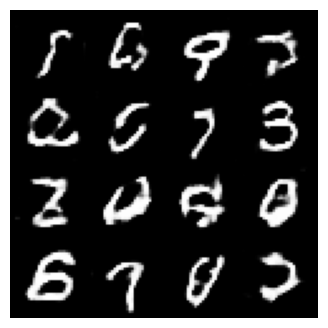

In [ ]:

cla_batch = 64
cla_transform = transforms.ToTensor()  # [0,1]
cla_train_loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=cla_transform),
    batch_size=cla_batch, shuffle=True
)

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),  # 28×28 → 28×28
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 14×14
            nn.Conv2d(32, 64, 3, 1, 1), # → 14×14
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 7×7
            nn.Flatten(),               # → 64*7*7
            nn.Linear(64*7*7, 128),
            nn.ReLU(True),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

classifier = MNISTClassifier().to(device)
opt_C = optim.Adam(classifier.parameters(), lr=1e-3)
criterion_C = nn.CrossEntropyLoss()

for epoch in range(3):
    classifier.train()
    total, correct = 0, 0
    for imgs, labels in cla_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = classifier(imgs)
        loss = criterion_C(logits, labels)
        opt_C.zero_grad(); loss.backward(); opt_C.step()

        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    acc = correct / total
    print(f"Classifier Epoch {epoch+1}/3 – Accuracy: {acc:.4f}")


def compute_fid(real_imgs: torch.Tensor, fake_imgs: torch.Tensor, device=device) -> float:
    real_uint8 = (real_imgs * 255).to(torch.uint8)
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    fid = FrechetInceptionDistance(feature=2048).to(device)
    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    return fid.compute().item()

def compute_inception_score(fake_imgs: torch.Tensor, device=device):
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    is_metric = InceptionScore(feature=2048).to(device)
    is_metric.update(fake_uint8)
    mean, std = is_metric.compute()
    return mean.item(), std.item()

def compute_mode_collapse(model, classifier, n_images=10000, device=device) -> float:
    model.eval(); classifier.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, device=device)
        fake = (model(z) + 1) / 2.0
        preds = classifier(fake).argmax(dim=1).cpu().tolist()
    seen = len(set(preds))
    return (1 - seen / 10.0) * 100 

def compute_psnr_ssim(real_images: torch.Tensor, fake_images: torch.Tensor):
    real_np = real_images.cpu().numpy()
    fake_np = fake_images.cpu().numpy()
    psnr_vals, ssim_vals = [], []
    for r, f in zip(real_np, fake_np):
        r2, f2 = r.squeeze(), f.squeeze()
        psnr_vals.append(psnr(r2, f2, data_range=1.0))
        ssim_vals.append(ssim(r2, f2, data_range=1.0))
    return sum(psnr_vals)/len(psnr_vals), sum(ssim_vals)/len(ssim_vals)


G.eval()

real_batch, _ = next(iter(train_loader))
real_small = (real_batch.to(device) + 1) / 2            # [0,1], [B,1,28,28]
real_for_fid = real_small.repeat(1,3,1,1)               # [B,3,28,28]
real_for_fid = F.interpolate(real_for_fid, size=(299,299), mode='bilinear')

with torch.no_grad():
    z = torch.randn(real_for_fid.size(0), latent_dim, device=device)
    fake_small = G(z).cpu().clamp(-1,1).add(1).div(2)   # [0,1], [B,1,28,28]
fake_for_fid = fake_small.repeat(1,3,1,1)
fake_for_fid = F.interpolate(fake_for_fid, size=(299,299), mode='bilinear')

fid_val = compute_fid(real_for_fid, fake_for_fid, device)
print(f"FID:                 {fid_val:.2f}")

is_mean, is_std = compute_inception_score(fake_for_fid, device)
print(f"Inception Score:     {is_mean:.2f} ± {is_std:.2f}")

mode_rate = compute_mode_collapse(G, classifier, device=device)
print(f"Mode Collapse Rate:  {mode_rate:.1f}%")

psnr_val, ssim_val = compute_psnr_ssim(real_small.cpu(), fake_small)
print(f"PSNR:                {psnr_val:.2f}")
print(f"SSIM:                {ssim_val:.3f}")

with torch.no_grad():
    z2 = torch.randn(16, latent_dim, device=device)
    samples = (G(z2).cpu().clamp(-1,1).add(1).div(2))   # [0,1], [16,1,28,28]
grid = make_grid(samples, nrow=4)
plt.figure(figsize=(4,4))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()


10 epochs made the generator behave worse than 30 epochs. So I will try to optimize it through tunning the hyperparameters and different classical layers. 

Epoch  1 | D-loss: 0.6419 | G-loss: 0.8205
Epoch  2 | D-loss: 0.6417 | G-loss: 0.8383
Epoch  3 | D-loss: 0.6206 | G-loss: 0.8663
Epoch  4 | D-loss: 0.6124 | G-loss: 0.8773
Epoch  5 | D-loss: 0.6131 | G-loss: 0.8744
Epoch  6 | D-loss: 0.6172 | G-loss: 0.8754
Epoch  7 | D-loss: 0.6184 | G-loss: 0.8765
Epoch  8 | D-loss: 0.6183 | G-loss: 0.8772
Epoch  9 | D-loss: 0.6176 | G-loss: 0.8810
Epoch 10 | D-loss: 0.6171 | G-loss: 0.8811
Epoch 11 | D-loss: 0.6163 | G-loss: 0.8847
Epoch 12 | D-loss: 0.6154 | G-loss: 0.8884
Epoch 13 | D-loss: 0.6144 | G-loss: 0.8897
Epoch 14 | D-loss: 0.6138 | G-loss: 0.8900
Epoch 15 | D-loss: 0.6131 | G-loss: 0.8925
Epoch 16 | D-loss: 0.6121 | G-loss: 0.8940
Epoch 17 | D-loss: 0.6111 | G-loss: 0.8940
Epoch 18 | D-loss: 0.6110 | G-loss: 0.8963
Epoch 19 | D-loss: 0.6099 | G-loss: 0.8976
Epoch 20 | D-loss: 0.6099 | G-loss: 0.8971
Epoch 21 | D-loss: 0.6088 | G-loss: 0.8975
Epoch 22 | D-loss: 0.6082 | G-loss: 0.8995
Epoch 23 | D-loss: 0.6074 | G-loss: 0.8978
Epoch 24 | 

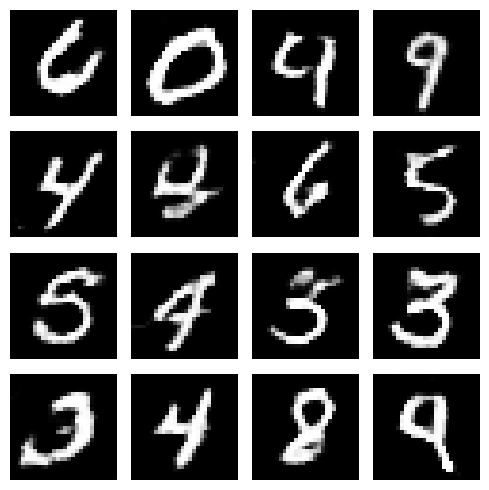

In [ ]:

batch_size = 128
latent_dim = 100
n_qubits   = 8
q_depth    = 3
lr         = 2e-4   
n_epochs   = 30    
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_loader = DataLoader(
    datasets.MNIST(".", train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev, interface="torch")
def qcircuit(inputs, weights):
    for i in range(n_qubits):
        qml.RX(inputs[..., i], wires=i)
        qml.RY(inputs[..., i + n_qubits], wires=i)
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

weight_shapes = {"weights": (q_depth, n_qubits)}
quantum_layer = TorchLayer(qcircuit, weight_shapes).to(device)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.init_size = 7
        self.fc     = nn.Linear(latent_dim, 128 * self.init_size**2)
        self.pre_q  = nn.Linear(128, 2 * n_qubits)
        self.post_q = nn.Linear(n_qubits, 128)
        self.upsample = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 14×14
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1),    # 28×28
            nn.Tanh()
        )

    def forward(self, z):
        batch = z.size(0)
        x = self.fc(z).view(batch, 128, self.init_size, self.init_size)
        feat   = x.mean(dim=[2,3])
        angles = torch.tanh(self.pre_q(feat)) * torch.pi
        q_out  = quantum_layer(angles)
        fusion = self.post_q(q_out).view(batch, 128, 1, 1)
        img = self.upsample(x * (1 + fusion))
        return img

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.down = nn.Sequential(
            spectral_norm(nn.Conv2d(1, 16, 3, stride=2, padding=1)),
            nn.LeakyReLU(0.2, True),
            spectral_norm(nn.Conv2d(16, 32, 3, stride=2, padding=1)),
            nn.LeakyReLU(0.2, True),
            spectral_norm(nn.Conv2d(32, 64, 3, stride=2, padding=1)),
            nn.LeakyReLU(0.2, True),
            nn.Flatten(),
        )
        self.fc1    = spectral_norm(nn.Linear(64*4*4, 128))
        self.pre_q  = spectral_norm(nn.Linear(128, 2 * n_qubits))
        self.post_q = spectral_norm(nn.Linear(n_qubits, 1))

    def forward(self, img):
        img = img + 0.05 * torch.randn_like(img)
        batch = img.size(0)
        x    = self.down(img)
        feat = torch.relu(self.fc1(x))
        angles = torch.tanh(self.pre_q(feat)) * torch.pi
        q_out  = quantum_layer(angles)
        validity = torch.sigmoid(self.post_q(q_out))
        return validity

G = Generator().to(device)
D = Discriminator().to(device)
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5,0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5,0.999))
sched_G = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=n_epochs)
sched_D = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=n_epochs)
criterion = nn.BCELoss()

for epoch in range(1, n_epochs+1):
    g_loss_acc, d_loss_acc = 0., 0.
    for real, _ in train_loader:
        real = real.to(device)
        b    = real.size(0)
        real_labels = torch.full((b,1), 0.9, device=device)
        fake_labels = torch.zeros((b,1), device=device)

        opt_D.zero_grad()
        loss_real = criterion(D(real), real_labels)
        fake = G(torch.randn(b, latent_dim, device=device)).detach()
        loss_fake = criterion(D(fake), fake_labels)
        d_loss = 0.5 * (loss_real + loss_fake)
        d_loss.backward()
        opt_D.step()

        opt_G.zero_grad()
        g_loss = criterion(D(G(torch.randn(b, latent_dim, device=device))), real_labels)
        g_loss.backward()
        opt_G.step()

        d_loss_acc += d_loss.item()
        g_loss_acc += g_loss.item()

    sched_G.step()
    sched_D.step()

    print(f"Epoch {epoch:2d} | D-loss: {d_loss_acc/len(train_loader):.4f} | G-loss: {g_loss_acc/len(train_loader):.4f}")

G.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    samples = G(z).cpu().squeeze().numpy()

fig, axs = plt.subplots(4,4, figsize=(5,5))
for ax, img in zip(axs.flatten(), samples):
    ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
plt.tight_layout()
plt.show()


Classifier Epoch 1 - Acc: 0.9374
Classifier Epoch 2 - Acc: 0.9838
Classifier Epoch 3 - Acc: 0.9891
FID:                 9.09
Inception Score:     2.19 ± 0.08
Mode Collapse Rate:  0.0%
PSNR:                8.87
SSIM:                0.202


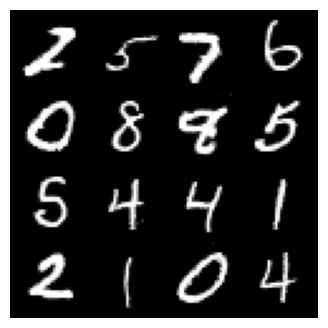

In [ ]:

cla_batch = 64
cla_transform = transforms.ToTensor()  # [0,1]
cla_train_loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=cla_transform),
    batch_size=cla_batch, shuffle=True
)

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),  # 28×28 → 28×28
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 14×14
            nn.Conv2d(32, 64, 3, 1, 1), # → 14×14
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 7×7
            nn.Flatten(),               # → 64*7*7
            nn.Linear(64*7*7, 128),
            nn.ReLU(True),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

classifier = MNISTClassifier().to(device)
opt_C = optim.Adam(classifier.parameters(), lr=1e-3)
criterion_C = nn.CrossEntropyLoss()

for epoch in range(3):
    classifier.train()
    total, correct = 0, 0
    for imgs, labels in cla_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = classifier(imgs)
        loss = criterion_C(logits, labels)
        opt_C.zero_grad(); loss.backward(); opt_C.step()

        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    acc = correct / total
    print(f"Classifier Epoch {epoch+1}/3 – Accuracy: {acc:.4f}")


def compute_fid(real_imgs: torch.Tensor, fake_imgs: torch.Tensor, device=device) -> float:
    real_uint8 = (real_imgs * 255).to(torch.uint8)
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    fid = FrechetInceptionDistance(feature=2048).to(device)
    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    return fid.compute().item()

def compute_inception_score(fake_imgs: torch.Tensor, device=device):
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    is_metric = InceptionScore(feature=2048).to(device)
    is_metric.update(fake_uint8)
    mean, std = is_metric.compute()
    return mean.item(), std.item()

def compute_mode_collapse(model, classifier, n_images=10000, device=device) -> float:
    model.eval(); classifier.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, device=device)
        fake = (model(z) + 1) / 2.0
        preds = classifier(fake).argmax(dim=1).cpu().tolist()
    seen = len(set(preds))
    return (1 - seen / 10.0) * 100 

def compute_psnr_ssim(real_images: torch.Tensor, fake_images: torch.Tensor):
    real_np = real_images.cpu().numpy()
    fake_np = fake_images.cpu().numpy()
    psnr_vals, ssim_vals = [], []
    for r, f in zip(real_np, fake_np):
        r2, f2 = r.squeeze(), f.squeeze()
        psnr_vals.append(psnr(r2, f2, data_range=1.0))
        ssim_vals.append(ssim(r2, f2, data_range=1.0))
    return sum(psnr_vals)/len(psnr_vals), sum(ssim_vals)/len(ssim_vals)


G.eval()

real_batch, _ = next(iter(train_loader))
real_small = (real_batch.to(device) + 1) / 2            # [0,1], [B,1,28,28]
real_for_fid = real_small.repeat(1,3,1,1)               # [B,3,28,28]
real_for_fid = F.interpolate(real_for_fid, size=(299,299), mode='bilinear')

with torch.no_grad():
    z = torch.randn(real_for_fid.size(0), latent_dim, device=device)
    fake_small = G(z).cpu().clamp(-1,1).add(1).div(2)   # [0,1], [B,1,28,28]
fake_for_fid = fake_small.repeat(1,3,1,1)
fake_for_fid = F.interpolate(fake_for_fid, size=(299,299), mode='bilinear')

fid_val = compute_fid(real_for_fid, fake_for_fid, device)
print(f"FID:                 {fid_val:.2f}")

is_mean, is_std = compute_inception_score(fake_for_fid, device)
print(f"Inception Score:     {is_mean:.2f} ± {is_std:.2f}")

mode_rate = compute_mode_collapse(G, classifier, device=device)
print(f"Mode Collapse Rate:  {mode_rate:.1f}%")

psnr_val, ssim_val = compute_psnr_ssim(real_small.cpu(), fake_small)
print(f"PSNR:                {psnr_val:.2f}")
print(f"SSIM:                {ssim_val:.3f}")

with torch.no_grad():
    z2 = torch.randn(16, latent_dim, device=device)
    samples = (G(z2).cpu().clamp(-1,1).add(1).div(2))   # [0,1], [16,1,28,28]
grid = make_grid(samples, nrow=4)
plt.figure(figsize=(4,4))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()


The generated images looks good to me, each of them are accurate and there are diversity. Thus, I believe what's not working is the eveluation metrix. FID is not as good in evaluating quantum GAN, we should consider other metrics like gsoc 2024 contributer suggested. 